In [8]:
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits
import astropy.coordinates
import fitsio
import sdss_access
import pandas as pd
import astropy.units as u
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

In [9]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

In [10]:
allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('',full=allspec_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()


In [11]:
# this step is slow give it time the allspec file is enormous
allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

Find a sky position from e.g. your exploration of the sky using SkyServer on Monday and enter its RA and Dec below in degrees

In [12]:
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
sep = sep.value   # grabbing the seperation from objects and target location(degrees)


[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_82/3257363055.py", line 11, in <module>
    indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
NameError: name 'center_coords' is not defined



# N. Rumbaugh sample EVQs with epochs greater than 25



matches=[]
for i in range(len(data_file)):
    # Search the master index
    tolerance = 0.0005
    mask_4 = (np.abs(allspec['ra'] - data_file['RAdeg'][i]) < tolerance) & \
             (np.abs(allspec['dec'] - data_file['DEdeg'][i]) < tolerance)

    epoch_count_4 = np.sum(mask_4)
    
    

    if epoch_count_4 > 25:
        matches.append((data_file['RAdeg'][i], data_file['DEdeg'][i], epoch_count_4))
        
    else:
        pass

In [13]:
data_file = pd.read_csv('EVQ_sample_new1.txt', sep='\s+', header=None, names=['DR7Qid','RAdeg', 'DEdeg','zspec','MJD-lo','gmag-lo','e_gmag-lo','MJD-hi','gmag-hi','e_gmag-hi','fFIRST'])

data_file

,DR7Qid,RAdeg,DEdeg,zspec,MJD-lo,gmag-lo,e_gmag-lo,MJD-hi,gmag-hi,e_gmag-hi,fFIRST
0,28,0.175101,-0.750386,1.3115,52931.22,20.900,0.040,51081.00,19.857,0.023,0
1,33,0.192320,-0.501993,1.4453,54373.38,20.636,0.100,51075.30,19.459,0.022,0
2,50,0.268872,0.464944,0.5512,56546.27,21.238,0.017,51819.36,20.189,0.026,0
3,90,0.537709,0.098022,2.1447,54387.33,21.367,0.054,51819.36,20.204,0.027,0
4,97,0.579628,0.375815,0.5467,53314.21,20.722,0.036,52253.19,19.699,0.035,0
...,...,...,...,...,...,...,...,...,...,...,...
972,105735,359.710846,0.054231,2.0050,51819.36,21.074,0.040,53975.30,20.030,0.029,0
973,105749,359.788269,0.961563,1.1687,53705.21,21.783,0.084,51819.36,20.510,0.032,0
974,105756,359.829803,-0.522517,0.8365,53312.20,21.575,0.103,51075.30,20.152,0.026,0
975,105766,359.903412,-0.520211,1.0956,56932.24,22.386,0.048,52231.20,20.208,0.038,1


In [14]:
data_file.to_csv('EVQ_sample.csv')

In [15]:
# SDSS ID of the EVQs that had epochs higher than 25
EVQs_NRum = [(40.27108, -0.859079, 27), (40.67067, 0.364116, 28), (41.331882, -0.853615, 28), (41.390282, -0.129178, 30), (41.635605, 0.091385, 27)]
# One was lost due to data possibly being inaccurate
# EVQ_sample= [
#     'SDSSJ024105.06-005132.6',
#     'SDSSJ024240.95+002150.8',
#     'SDSSJ024519.65-005113.0',
#     'SDSSJ024533.66-000745.0',
#     'SDSSJ024632.54+000529.0'
# ]


In [16]:
tolerance = 0.005
target_ras = [] 
target_decs = []

for ra, dec, n in EVQs_NRum:
    target_ras.append(ra)
    target_decs.append(dec)
    
target_coords = astropy.coordinates.SkyCoord(
    target_ras,
    target_decs,
    unit='deg'
)
# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target_coords.match_to_catalog_sky(unique_coords)
EVQ_sdss_ids = []

for i in range(len(indx)):
    EVQ_sdss_ids.append(unique_sdss_id[indx[i]])
    print(EVQ_sdss_ids)
print(sep.to(u.arcsec).value)

[70100578]
[70100578, 70109698]
[70100578, 70109698, 70104152]
[70100578, 70109698, 70104152, 70108499]
[70100578, 70109698, 70104152, 70108499, 70108663]
[0.16683032 0.0641739  0.19184862 0.03234747 0.06126656]


In [17]:
url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')


In [18]:
EVQs_rows = []
download_files = []
EVQ_ids= []
for sdss_id in EVQ_sdss_ids:
    rows = allspec[allspec['sdss_id'] == sdss_id]
    EVQs_rows.append(rows)
    print(sdss_id, "Number of epochs:", len(rows))
    
    

70100578 Number of epochs: 27
70109698 Number of epochs: 28
70104152 Number of epochs: 28
70108499 Number of epochs: 30
70108663 Number of epochs: 27


In [19]:
EVQs_spec= []
download_files= []
for obj_rows in EVQs_rows:
    for row in obj_rows:
        
        sas_url = row['sas_url'].decode()
        local_path = sas_url.replace(url_root, local_root)
        EVQs_spec.append((local_path, row["mjd"], row["sdss_id"]))

        if not os.path.exists(local_path):
            download_files.append(sas_url)



In [20]:
if len(download_files) > 0:
    print("fetching files, please stand by")
    access.remote()
    access.set_stream()
    
    for url in download_files:
        access.add(url)

# disable follow_symlinks
    access.commit(follow_symlinks=False)

In [49]:
spectra = []

for path, mjd, sdss_id in EVQs_spec:
    with astropy.io.fits.open(path) as hdul:
    
        if 'COADD' in hdul:
            coadd = hdul['COADD'].data
        else:
            coadd = hdul['SPECTRUM'].data


        wavelength = 10**coadd['loglam']
        flux = coadd['flux']

        spectra.append({
            "wavelength": wavelength,
            "flux": flux,
            "mjd": mjd,
            "sdss_id": sdss_id
})


140

In [22]:
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('',full=spall_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()
print(spall_file)

spall_columns = ['SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS', 'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG']
spall = fitsio.read(spall_file, columns=spall_columns)


/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


In [23]:
EVQ_z = []

for evq_id in EVQ_sdss_ids:
    
    mask  = spall['SDSS_ID']== evq_id
    z_val = spall['Z'][mask]
    EVQ_z.append(np.nanmedian(z_val))
    

In [24]:
EVQ_z

[1.7848403, 0.6323479, 1.5447837, 0.65524626, 1.306677]

In [25]:
rest_lambda = {
    "OVI":     1034.0,
    "Lyalpha": 1216.0,
    "CIV":     1549.0,
    "CIII":    1908.0,
    "MGII":    2799.0,
    "Hbeta":   4862.0,
    "Hgamma":  4361.0,
    "Halpha":  6564.0
}
# We are doing our analysis with Hbeta and H alpha
lmbd_rst_Hbeta = rest_lambda['Hbeta']
lmbd_rst_Halpha = rest_lambda['Halpha']
cntr_Hbeta = []
cntr_Halpha = []
for z in EVQ_z:
    cntr_hb = lmbd_rst_Hbeta * (1+z)
    cntr_Hbeta.append(cntr_hb)
    cntr_ha = lmbd_rst_Halpha * (1+z)
    cntr_Halpha.append(cntr_ha)

    print(f'Hβ observed center: {cntr_hb:.2f} Å')
    print(f'Hα observed center: {cntr_ha:.2f} Å')


Hβ observed center: 13539.89 Å
Hα observed center: 18279.69 Å
Hβ observed center: 7936.48 Å
Hα observed center: 10714.73 Å
Hβ observed center: 12372.74 Å
Hα observed center: 16703.96 Å
Hβ observed center: 8047.81 Å
Hα observed center: 10865.04 Å
Hβ observed center: 11215.06 Å
Hα observed center: 15141.03 Å


In [26]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

In [27]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

In [116]:
center_map = dict(zip(EVQ_sdss_ids, zip(cntr_Hbeta, cntr_Halpha)))
for sdss_id, (cntrHb, cntrHa) in center_map.items():
    print(sdss_id, cntrHb, cntrHa)

70100578 13539.89375925064 18279.69202709198
70109698 7936.4754012823105 10714.731496095657
70104152 12372.738404989243 16703.960281848907
70108499 8047.8073053359985 10865.036436080933
70108663 11215.063495397568 15141.027721881866


In [115]:
plt.close('all')

# $H\beta$

### Let's look at Hbeta emission spectrum

3814.169 9200.257
3590.0457 10382.458
3603.2964 10394.412
3604.1252 10360.958
3607.447 10392.016
3608.2788 10384.841
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206


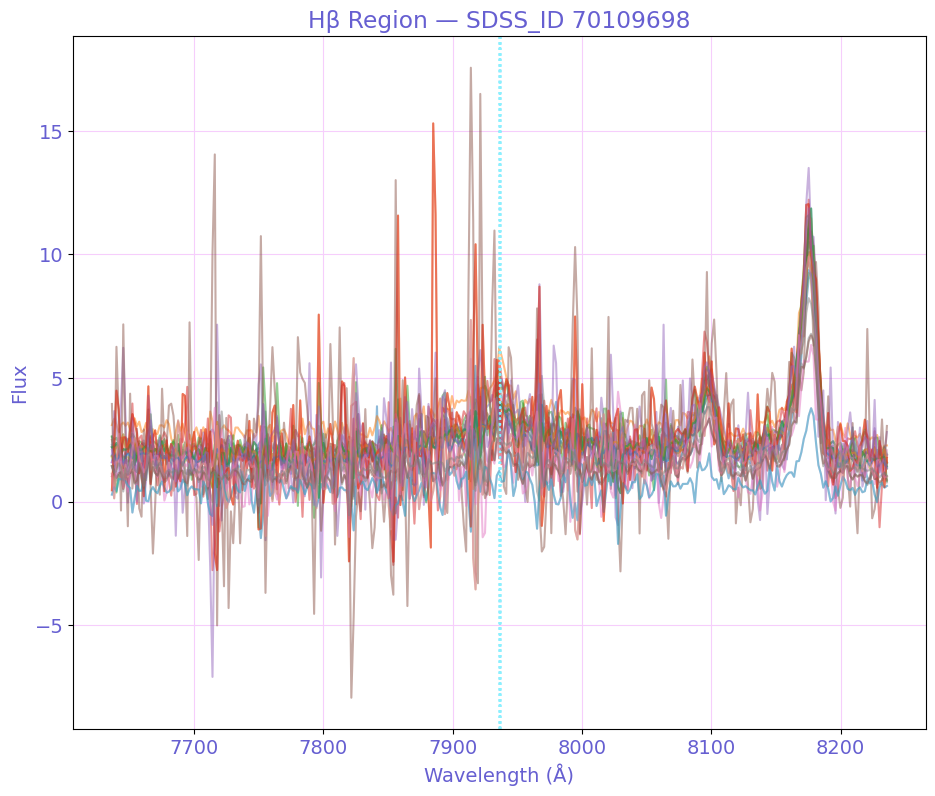

3801.8933 9221.464
3808.0261 9198.141
3560.4106 10329.994
3562.0508 10344.272
3565.3318 10341.888
3564.5117 10341.888
3590.8735 10363.348
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206


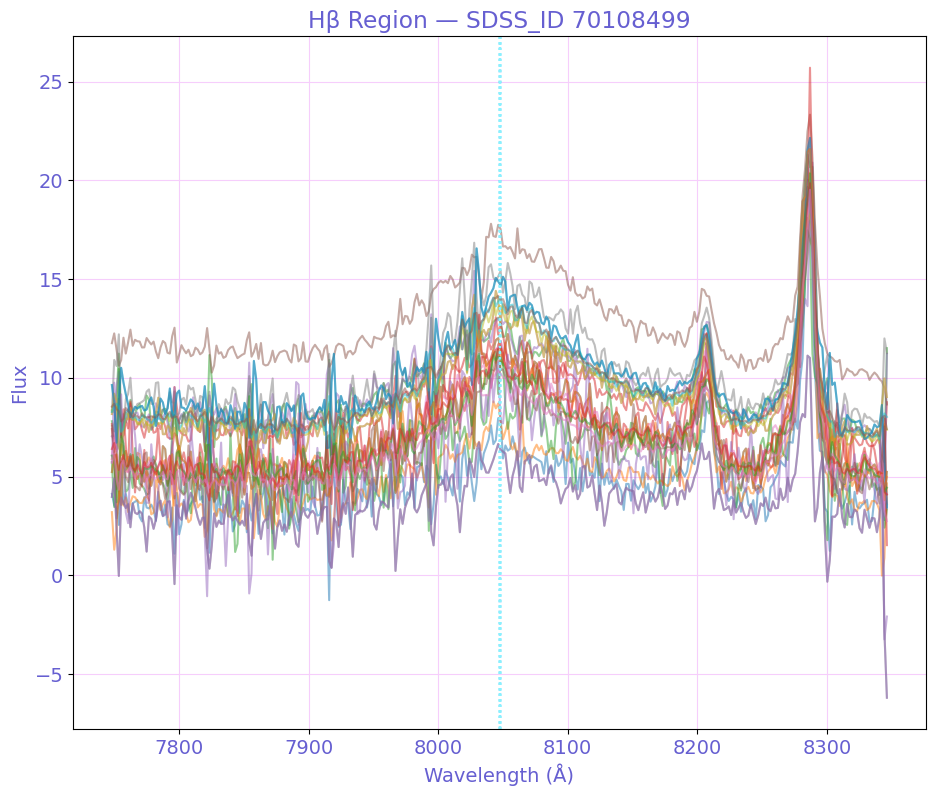

In [136]:
plt.rcParams['figure.figsize'] = [15,10]
max_flux_Hb = []
for target_id in [70109698, 70108499]:
    cntrHb , cntrHa = center_map[target_id]
    plt.figure(figsize=(11,9))
    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]
            
            
            mask_beta = (wl > cntrHb - 300) & (wl < cntrHb + 300)
            
            max_flux = np.max(fl[mask_beta])
            
            max_flux_Hb.append(max_flux)
            if max_flux == 0 or not np.isfinite(max_flux):
                continue
            
            #print(max_flux_Hb)
            plt.axvline(x=cntrHb, color="xkcd:robin egg blue", linestyle=':', label='Hβ observed center') 
            
            plt.plot(wl[mask_beta], fl[mask_beta], alpha=0.5)
    plt.xlabel("Wavelength (Å)", color= "xkcd:dark periwinkle")
    plt.ylabel("Flux", color= "xkcd:dark periwinkle")
     
    plt.title(f"Hβ Region — SDSS_ID {target_id}", color= "xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color= "xkcd:very light purple")
    plt.show()
      

In [46]:
print(fl)
print(len(fl))

[-1.3162888e+07  2.7921882e+07 -2.7525632e+07 ... -2.0730415e+01
 -2.0730415e+01 -2.0730415e+01]
4648


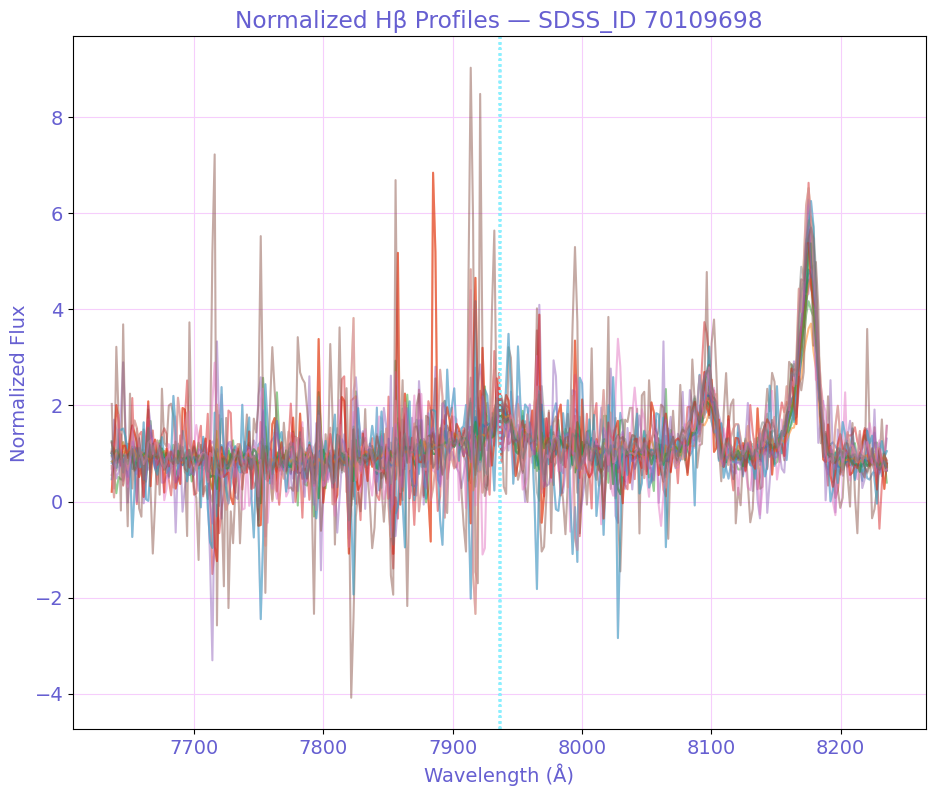

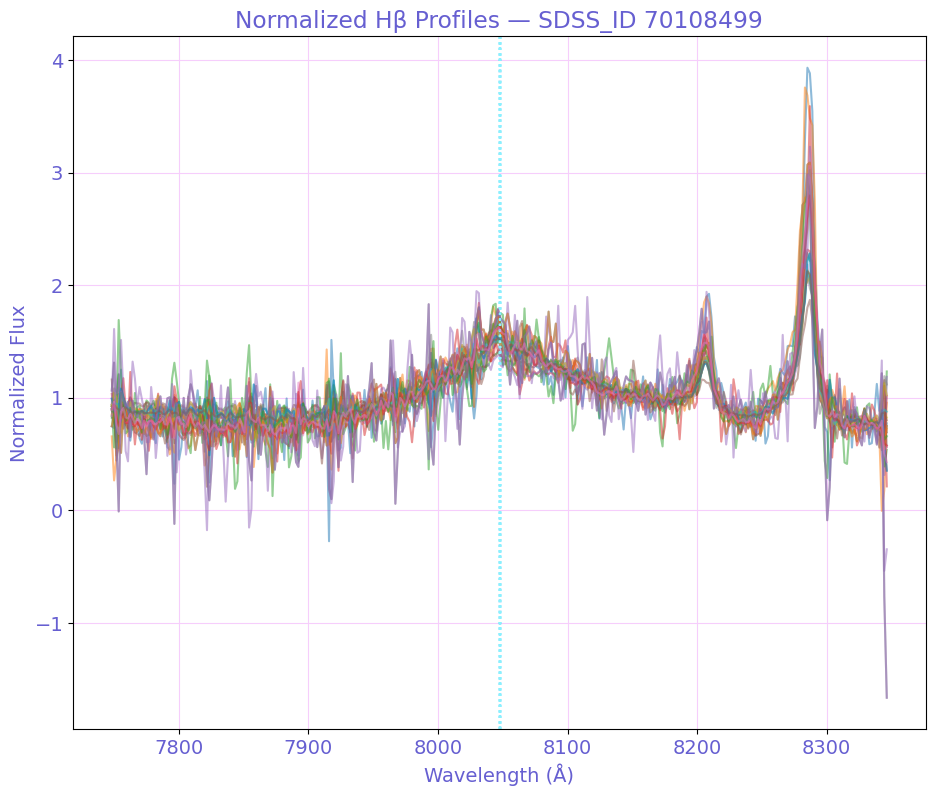

In [138]:
plt.rcParams['figure.figsize'] = [15,10]
max_flux_normHb = [] 
for target_id in [70109698, 70108499]:
    cntrHb , cntrHa = center_map[target_id]
    plt.figure(figsize=(11,9))
    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]

            mask_beta = (wl > cntrHb - 300) & (wl < cntrHb + 300)
            wl_zoom   = wl[mask_beta]
            fl_zoom   = fl[mask_beta]
            max_flux = np.max(fl_zoom)
            max_flux_normHb.append(max_flux)
            if max_flux == 0 or not np.isfinite(max_flux):
                continue
            #print(max_flux_normHa)
            
            plt.axvline(x=cntrHb, color="xkcd:robin egg blue", linestyle=':', label='Hβ observed center')
            cont = continuum_flux(wl_zoom, fl_zoom, cntrHb - 250, cntrHb + 150)
            plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

    plt.xlabel("Wavelength (Å)", color= "xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux", color= "xkcd:dark periwinkle")
    plt.title(f"Normalized Hβ Profiles — SDSS_ID {target_id}", color= "xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color= "xkcd:very light purple")
    plt.show();



# $H\alpha$

3814.169 9200.257
3590.0457 10382.458
3603.2964 10394.412
3604.1252 10360.958
3607.447 10392.016
3608.2788 10384.841
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206


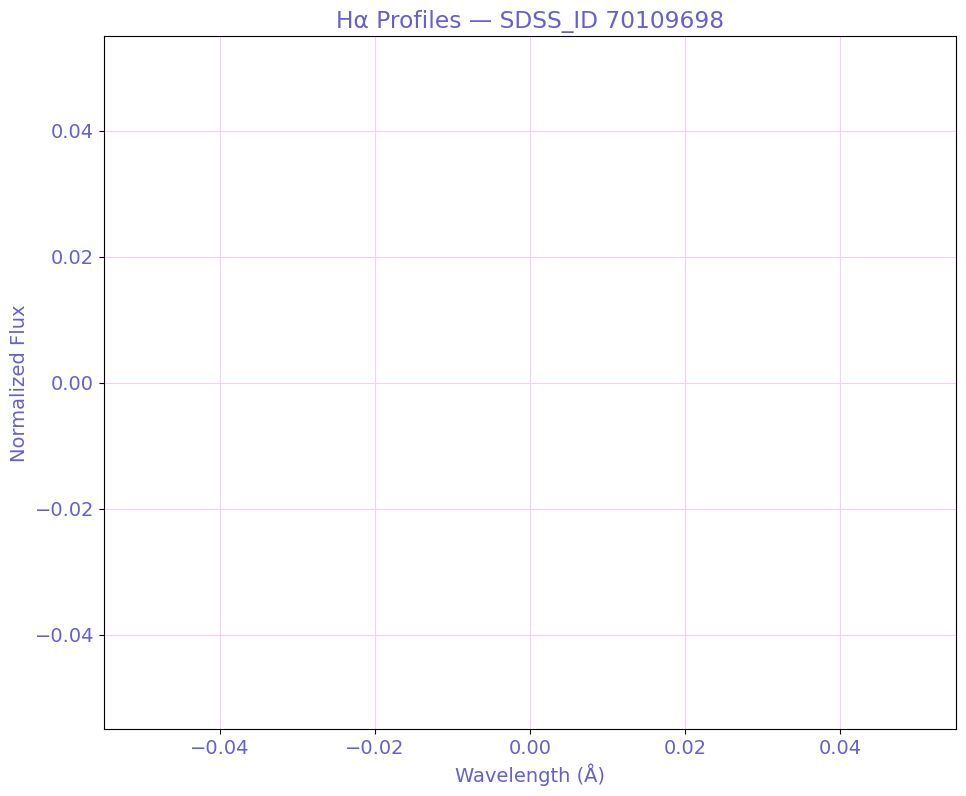

3801.8933 9221.464
3808.0261 9198.141
3560.4106 10329.994
3562.0508 10344.272
3565.3318 10341.888
3564.5117 10341.888
3590.8735 10363.348
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206
3566.9744 10399.206


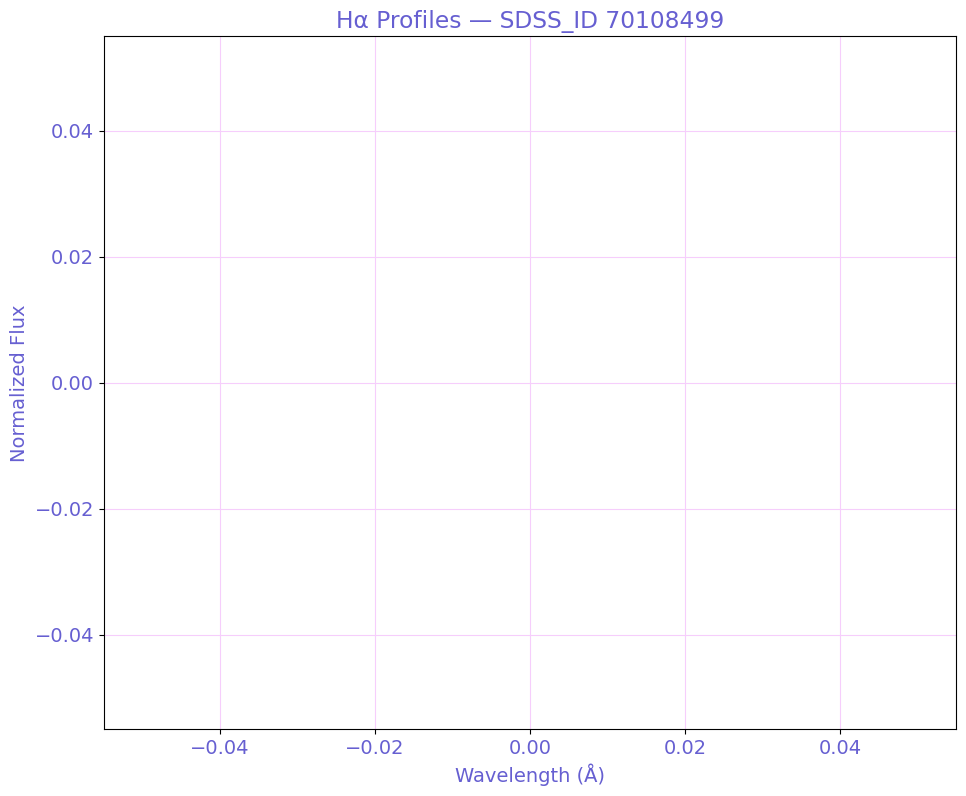

In [144]:
matplotlib.rcParams['text.usetex'] = False
max_flux_Ha = []
for target_id in [70109698, 70108499]:
    cntrHb , cntrHa = center_map[target_id]
    plt.figure(figsize=(11,9))
    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]
                
            mask_alpha = (wl > cntrHa - 150) & (wl < cntrHa + 150)
           
            print(np.min(wl), np.max(wl)) 
            # The Halpha emission line is > than the max value in the flux for this object 
            #print(max_flux_normHa)
            plt.plot(wl[mask_alpha], fl[mask_alpha], alpha=0.5)
    plt.xlabel("Wavelength (Å)", color= "xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux", color= "xkcd:dark periwinkle")
    plt.title(f"Hα Profiles — SDSS_ID {target_id}", color= "xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color= "xkcd:very light purple")
    plt.show();    
            

### Hβ observed center: 7936.48 Å
### Hα observed center: 10714.73 Å
### Hβ observed center: 8047.81 Å
### Hα observed center: 10865.04 Å


## This is out of the scope of sdss wavelength coverage

[9.269293]
[9.269293, 11.4665]
[9.269293, 11.4665, 10.520235]
[9.269293, 11.4665, 10.520235, 10.934477]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894, 11.588114]
[9.269293, 11.4665, 10.520235, 10.934477, 11.07

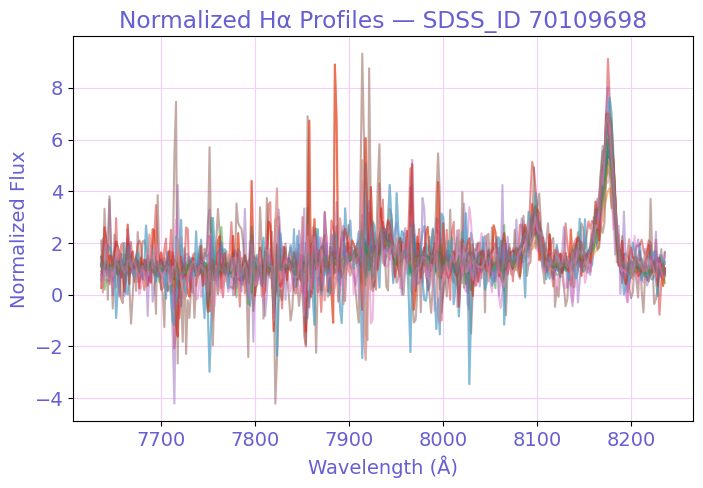

[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894, 11.588114, 12.216984, 13.502566, 17.558743, 6.3384557, 6.789296, 9.913042, 3.777226, 9.368771, 10.181666, 11.861691, 15.305894, 11.86682, 6.724728, 9.913042, 8.232361, 0.0, 18.110735]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894, 11.588114, 12.216984, 13.502566, 17.558743, 6.3384557, 6.789296, 9.913042, 3.777226, 9.368771, 10.181666, 11.861691, 15.305894, 11.86682, 6.724728, 9.913042, 8.232361, 0.0, 18.110735, 18.279232]
[9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894, 11.588114, 12.216984, 13.502566, 17.558743, 6.3384557, 6.789296, 9.913042, 3.777226, 9.368771, 10.181666, 11.861691, 15.305894, 11.86682, 6.724728, 9.913042, 8.232361, 0.0, 18.110735, 18.279232, 21.305365]
[9.269293, 11.4665, 10.520235, 10.934

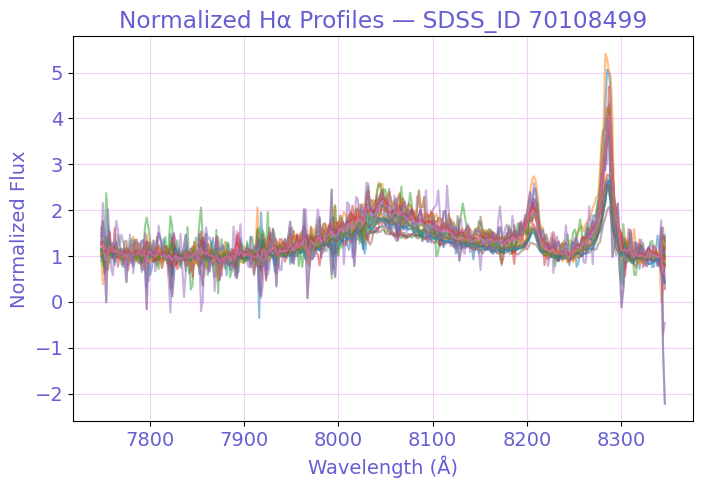

58 [9.269293, 11.4665, 10.520235, 10.934477, 11.071697, 10.090304, 3.777226, 9.69004, 9.256099, 10.181666, 11.861691, 15.305894, 11.588114, 12.216984, 13.502566, 17.558743, 6.3384557, 6.789296, 9.913042, 3.777226, 9.368771, 10.181666, 11.861691, 15.305894, 11.86682, 6.724728, 9.913042, 8.232361, 0.0, 18.110735, 18.279232, 21.305365, 20.031572, 20.906637, 23.332952, 18.30477, 21.298758, 19.052301, 22.15795, 0.0, 21.592955, 20.39325, 17.47227, 25.71263, 19.552525, 19.888153, 19.990217, 11.125255, 18.30477, 19.464775, 22.15795, 0.0, 21.592955, 20.354546, 19.857836, 11.125255, 19.668602, 19.53121]


In [83]:
matplotlib.rcParams['text.usetex'] = False
max_flux_normHa = []
for target_id in [70109698, 70108499]:
    cntr = center_map[target_id]
    plt.figure(figsize=(8,5))
    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]
            
            
            mask_alpha = (wl > cntrHa - 300) & (wl < cntrHa + 300)
            wl_zoom   = wl[mask_alpha]
            fl_zoom   = fl[mask_alpha]
            max_flux = np.max(fl_zoom)
            max_flux_normHa.append(np.max(max_flux))
            
            if max_flux == 0 or not np.isfinite(max_flux):
                continue
            print(max_flux_normHa)
            cont = continuum_flux(wl_zoom, fl_zoom, cntr - 250, cntr - 150)
            plt.plot(wl_zoom, fl_zoom / cont, alpha=0.5)

    plt.xlabel("Wavelength (Å)", color= "xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux", color= "xkcd:dark periwinkle")
    plt.title(f"Normalized Hα Profiles — SDSS_ID {target_id}",color= "xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color= "xkcd:very light purple")
    plt.show();

print(len(max_flux_normHa),max_flux_normHa)

In [85]:
max_flux_normHa_clean = [x for x in max_flux_normHa if x != 0 and np.isfinite(x)]
#print(len(max_flux_normHa_clean)) # got rid of the flux = 0

55


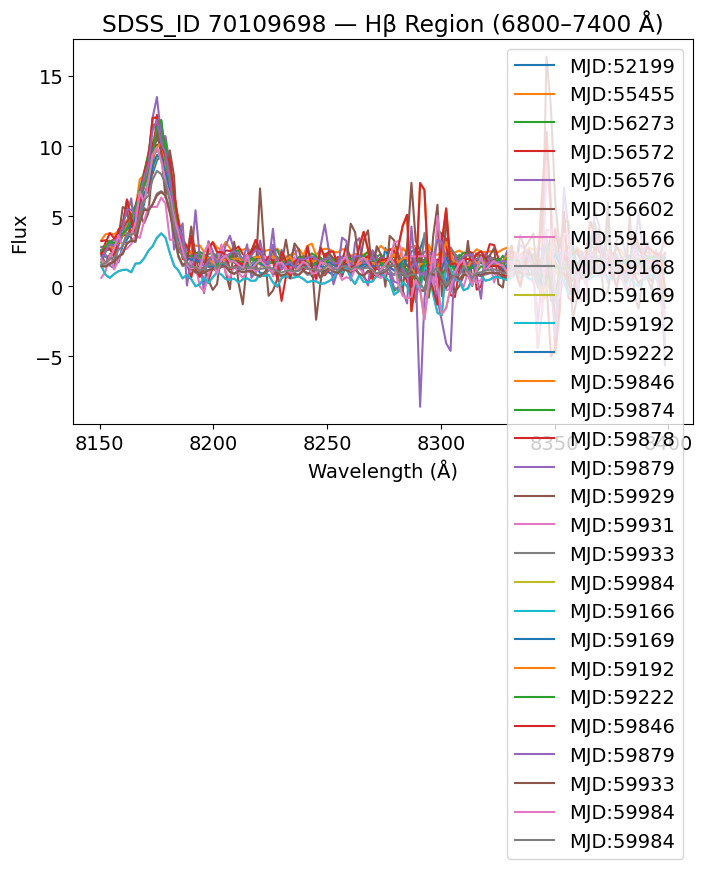

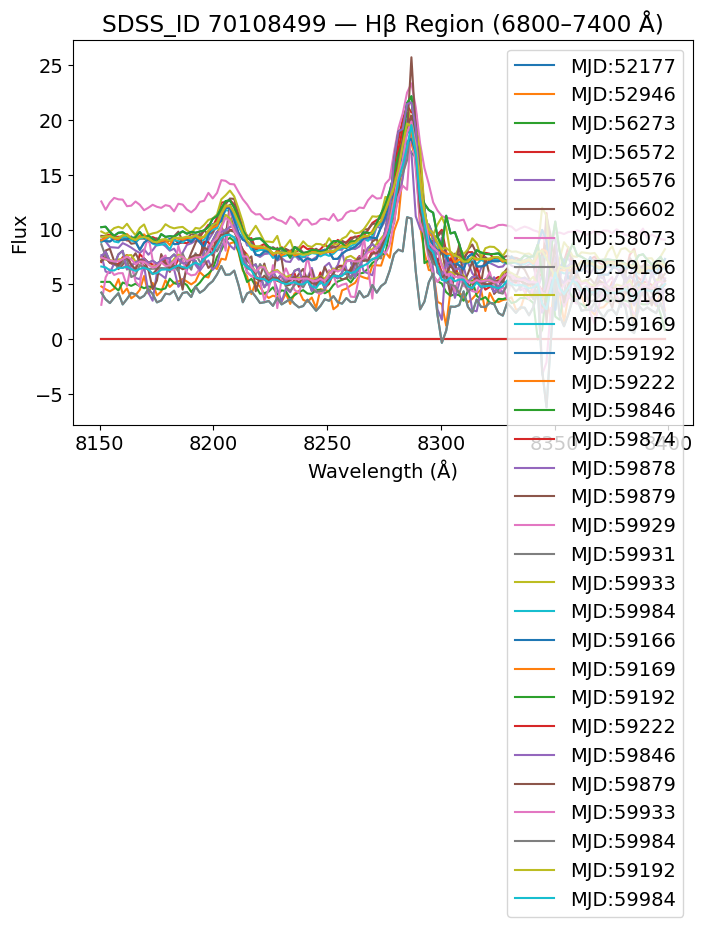

In [62]:
# plt.rcParams['figure.figsize'] = [20, 15] # I remember needing something liek this. It will error otherwise
# for target_id in [70109698, 70108499]:
#     cntr = center_map[target_id]
#     plt.figure(figsize=(8,5))
#     for s in spectra:
#         if s["sdss_id"] == target_id:
#             wl = s["wavelength"]
#             fl = s["flux"]

#             mask = (wl > 8150) & (wl < 8400)
#             max_flux = np.max(fl_zoom)
#             max_flux_normHa.append(np.max(max_flux))
            
#             if max_flux == 0 or not np.isfinite(max_flux):
#                 continue
#             print(max_flux_normHa)
#             plt.plot(wl[mask], fl[mask], label=f'MJD:{s["mjd"]}' )


#     plt.legend()
#     plt.xlabel("Wavelength (Å)")
#     plt.ylabel("Flux")
#     plt.title(f"SDSS_ID {target_id} — Hβ Region (6800–7400 Å)")
#     plt.show();


In [63]:
print(mjd.spectra())

[ERROR]: Traceback (most recent call last):
  File "/home/idies/mambaforge/envs/py39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3433, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_82/3998980867.py", line 1, in <module>
    print(mjd.spectra())
AttributeError: 'numpy.int32' object has no attribute 'spectra'

